## Imports and project setup

Import analysis libraries and project modules from `Synthetic/src`, then set the initial NumPy random seed.

Each complete run creates a timestamped folder under `local/results/`. All figures (PNG and PDF), per-seed/per-step numerical results, multi-seed summaries, and settings are saved together. Run the notebook from top to bottom; the final cell writes `all_results.csv` and marks the run complete. Re-running the setup cell starts a new folder.


In [1]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import yaml
import random
from collections import defaultdict
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple
import glob
import joblib

# Load project modules from Synthetic/src.
import sys
from pathlib import Path

src_path = Path("Synthetic/src")
if not src_path.is_dir():
    src_path = Path("../Synthetic/src")
src_path = src_path.resolve()
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from simulator import Bank, Agent as SimAgentBase, run_simulation
from evaluation import compute_statistics
from fair_model import FairModel
from activity_fair_model import ActivityAwareFairModel
from baselines import LR, CvxFairModel, EOFairModel
from utils import combine_tuples_active_only

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
# Execute this setup cell once per complete run to create a unique output directory.
from run_results import RunResults
run_results = RunResults(src_path.parents[1] / "local" / "results")
print(f"Run outputs: {run_results.folder}")

_compute_statistics = compute_statistics
import evaluation as _evaluation
DIAGNOSTIC_ESTIMATOR = ("clipped_decision_labels"
    if _evaluation.compute_post_long_cond_probs.__name__ == 'safe_compute_post_long_cond_probs'
    else "unclipped_decision_labels")
def compute_statistics(*args, **kwargs):
    records = _compute_statistics(*args, **kwargs)
    if run_results.last_context is not None:
        for record in records:
            for metric, value in record.items():
                if metric != 'step':
                    run_results.add(run_results.last_context,
                                    'diagnostic_' + DIAGNOSTIC_ESTIMATOR,
                                    metric, value, step=record['step'])
    return records


Run outputs: /Users/jh22215/Documents/GitHub/Delayed-Fairness-Project/local/results/20260917T135330_829319Z_7e8875


## Load the BAF datasets

Read all six local CSV files into `dataframes`, define dataset aliases, and create working copies of Base, Variant I, and Variant II.


In [2]:
# Reuse src_path, Path, and pd from the setup cell.
base_path = src_path.parents[1] / "local"
extension = "csv"

datasets_paths = {
    name: base_path / f"{name}.{extension}"
    for name in ["Base", "Variant I", "Variant II", "Variant III", "Variant IV", "Variant V"]
}

def read_dataset(path, ext=extension):
    if ext == "csv":
        return pd.read_csv(path)
    elif ext == "parquet":
        return pd.read_parquet(path)
    else:
        raise ValueError(f"Unsupported file extension: {ext}")

def get_variant(path):
    return Path(path).stem

data_paths = list(datasets_paths.values())
dataframes = {get_variant(path): read_dataset(path) for path in data_paths}
print(f"Loaded datasets: {list(dataframes.keys())}")

# Rename datasets
base = dataframes['Base']
variant1 = dataframes['Variant I']
variant2 = dataframes['Variant II']
variant3 = dataframes['Variant III']
variant4 = dataframes['Variant IV']
variant5 = dataframes['Variant V']

# For better display
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 50)

dfs = [base, variant1, variant2, variant3, variant4, variant5]

# Datasets used to compare group size (gs) and fraud prevalence (pr)
base_df = base.copy()  # majority: 77% gs, 0.9% pr; minority: 23% gs, 1.8% pr
v1_df = variant1.copy()  # majority: 90% gs, 1.1% pr; minority: 10% gs, 1.1% pr
v2_df = variant2.copy()  # majority: 50% gs, 0.4% pr; minority: 50% gs, 1.9% pr


Loaded datasets: ['Base', 'Variant I', 'Variant II', 'Variant III', 'Variant IV', 'Variant V']


## Select the working columns

Keep fraud labels, age, income, credit risk score, and proposed credit limit for the three datasets. The simulation later uses only the two credit features.


In [3]:
v1_simple = v1_df[['fraud_bool', 'customer_age', 'income','credit_risk_score', 'proposed_credit_limit']].copy()
v2_simple = v2_df[['fraud_bool', 'customer_age', 'income','credit_risk_score', 'proposed_credit_limit']].copy()
base_simple = base_df[['fraud_bool', 'customer_age', 'income','credit_risk_score', 'proposed_credit_limit']].copy()

## Define age groups

Set `S=0` for applicants younger than 50 and `S=1` for applicants aged 50 or above.


In [4]:
def add_age_group(df):
  df = df.copy()
  df['S'] = (df['customer_age'] >= 50).astype(int) # 1 = older minority
  return df

base_simple = add_age_group(base_simple)
v1_simple = add_age_group(v1_simple)
v2_simple = add_age_group(v2_simple)

## Inspect group sizes and fraud prevalence

Report each age group’s population share and fraud rate, plus the ratio of the higher to the lower fraud rate.


In [5]:
def group_stats(df,name):
  size = df['S'].value_counts(normalize=True) * 100
  rate0 = df.loc[df['S'] == 0, 'fraud_bool'].mean() * 100
  rate1 = df.loc[df['S'] == 1, 'fraud_bool'].mean() * 100
  ratio = max(rate0, rate1) / min(rate0, rate1) if min(rate0, rate1) > 0 else float('nan')
  print(f"===={name}===")
  print(f"  Group sizes:   S=0 (Younger)={size.get(0,0):.2f}%   S=1 (Older)={size.get(1,0):.2f}%")
  print(f"  Fraud rates:   S=0={rate0:.3f}%   S=1={rate1:.3f}%   ratio={ratio:.2f}x")
  print()

group_stats(base_simple, "Base")
group_stats(v1_simple, "Variant I")
group_stats(v2_simple, "Variant II")

====Base===
  Group sizes:   S=0 (Younger)=81.70%   S=1 (Older)=18.30%
  Fraud rates:   S=0=0.825%   S=1=2.341%   ratio=2.84x

====Variant I===
  Group sizes:   S=0 (Younger)=88.93%   S=1 (Older)=11.07%
  Fraud rates:   S=0=1.089%   S=1=1.216%   ratio=1.12x

====Variant II===
  Group sizes:   S=0 (Younger)=49.42%   S=1 (Older)=50.58%
  Fraud rates:   S=0=0.364%   S=1=1.825%   ratio=5.01x



## Split source rows and fit training-only scalers

Split each dataset 80/20, stratified by age group and fraud label. Source row IDs are disjoint within each dataset. Only training rows fit the scaler; the same transform is applied to held-out rows.

$$X_{j,i}^{(v)}=\frac{X_{j,i}^{\mathrm{raw},(v)}-\mu_{j,\mathrm{train}}^{(v)}}{\sigma_{j,\mathrm{train}}^{(v)}}.$$

Training/test agents later sample only from their respective pools. The split identifies rows within each file; BAF does not provide cross-variant person identities here.


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_COLS = ['credit_risk_score', 'proposed_credit_limit']


def split_feature_pools(df, test_size=0.2, seed=42):
    # Split source rows BEFORE fitting preprocessing or any model.
    row_ids = np.arange(len(df))
    train_ids, test_ids = train_test_split(
        row_ids, test_size=test_size, random_state=seed,
        stratify=df[['S', 'fraud_bool']],
    )
    train_df, test_df = df.iloc[train_ids].copy(), df.iloc[test_ids].copy()
    scaler = StandardScaler().fit(train_df[X_COLS].to_numpy(dtype=float))
    def pool(frame, ids):
        return {
            'features': scaler.transform(frame[X_COLS].to_numpy(dtype=float)),
            'age_groups': frame['S'].to_numpy(dtype=int),
            'fraud_labels': frame['fraud_bool'].to_numpy(dtype=int),
            'row_ids': ids,
        }
    assert not np.intersect1d(train_ids, test_ids).size
    return {'train': pool(train_df, train_ids), 'test': pool(test_df, test_ids),
            'scaler': scaler, 'train_df': train_df}


pools_base = split_feature_pools(base_simple)
pools_variant1 = split_feature_pools(v1_simple)
pools_variant2 = split_feature_pools(v2_simple)


## Fit repayment banks using training rows

Fit each Bank on its training pool only. Pass that Bank explicitly to both training and evaluation simulations; labels always come from the repayment Bank, including LCF-generated trajectories. No generator class parameters are patched.


In [7]:
def fit_repayment_bank(training_pool):
    calibration = LogisticRegression(max_iter=1000).fit(
        np.c_[training_pool['age_groups'], training_pool['features']],
        1 - training_pool['fraud_labels'],
    )
    return Bank(params=np.r_[calibration.coef_[0], calibration.intercept_[0]])


bank_base = fit_repayment_bank(pools_base['train'])
bank_variant1 = fit_repayment_bank(pools_variant1['train'])
bank_variant2 = fit_repayment_bank(pools_variant2['train'])

for dataset_name, repayment_bank in [
    ('Base', bank_base), ('Variant I', bank_variant1), ('Variant II', bank_variant2)
]:
    print(f'{dataset_name}: training-calibrated Bank.params = {repayment_bank.params}')


Base: training-calibrated Bank.params = [-0.8394557  -0.38935751 -0.24142869  4.92026479]
Variant I: training-calibrated Bank.params = [ 0.11703702 -0.41549847 -0.24489251  4.67371338]
Variant II: training-calibrated Bank.params = [-1.44770552 -0.40223813 -0.247416    5.72337699]


## Sample balanced initial populations

Define a shared initializer that samples equal numbers from the two age groups without replacement within each group, using the agent’s initialization seed.


In [8]:
class _BAFInitMixin:
    def __init__(self, s_pool, X_pool, n_samples, protect_ratio=0.5, eps=0.5,
                 base=(0.2, 1.0), seed=2021, row_ids=None, scaler=None):
        super().__init__(n_samples=n_samples, protect_ratio=protect_ratio,
                          eps=eps, base=base, seed=seed)
        self._s_pool = s_pool
        self._X_pool = X_pool
        self._row_ids = np.arange(len(s_pool)) if row_ids is None else np.asarray(row_ids)
        self.scaler = scaler

    def gen_init_profile(self):
        rng = np.random.default_rng(self.seed)
        n0 = np.where(self._s_pool == 0)[0]
        n1 = np.where(self._s_pool == 1)[0]
        # sample exactly n_samples/2 from each group so the population fed
        # into the graph generator is EXACTLY balanced, regardless of how imbalanced the source pool is
        half = self.n_samples // 2
        idx0 = rng.choice(n0, size=half, replace=False)
        idx1 = rng.choice(n1, size=self.n_samples - half, replace=False)
        idx = np.concatenate([idx0, idx1])
        rng.shuffle(idx)
        self.sampled_row_ids = self._row_ids[idx].copy()
        s = self._s_pool[idx].astype(float)
        X = self._X_pool[idx].copy()
        return s, X




## Define the longitudinal training agent

Use the simulator agent for training as well as evaluation. Training trajectories include network-driven opt-out and use the exact same credit-score update and credit-limit regeneration. There is no extra approval-probability multiplier or separately sampled repayment sign in the feature transition.


In [9]:
class BAFAgentTrain(_BAFInitMixin, SimAgentBase):
    """Training uses the same network and transition machinery as evaluation."""
    pass


## Define the simulation agent

Combine the BAF population initializer with the simulator agent’s behavior, including its peer-rejection calculations.


In [10]:
class BAFAgentSim(_BAFInitMixin, SimAgentBase):
    """For simulator.run_simulation() the actual networked simulation."""
    pass


## Compare feature correlations

Print the correlation between credit risk score and proposed credit limit in Base, Variant I, and Variant II.


In [11]:
print("Base:", base_simple[['credit_risk_score', 'proposed_credit_limit']].corr().iloc[0,1])
print("V1:  ", v1_simple[['credit_risk_score', 'proposed_credit_limit']].corr().iloc[0,1])
print("V2:  ", v2_simple[['credit_risk_score', 'proposed_credit_limit']].corr().iloc[0,1])

Base: 0.6061414475223358
V1:   0.5993240360135544
V2:   0.6310108985445129


## Fit credit-limit coupling on Base training rows

Fit $L=\widehat\alpha+\widehat\beta R+e$ on raw Base training rows only. Share this regression and residual spread across variants, but convert features using each variant's training-fitted scaler in both training and testing:

$$R_{i,t+1}=\mu_{1,\mathrm{train}}^{(v)}+\sigma_{1,\mathrm{train}}^{(v)}X_{1,i,t+1},\qquad \eta_{i,t+1}\sim\mathcal N(0,\widehat\sigma_e^2),$$
$$X_{2,i,t+1}=\frac{\widehat\alpha+\widehat\beta R_{i,t+1}+\eta_{i,t+1}-\mu_{2,\mathrm{train}}^{(v)}}{\sigma_{2,\mathrm{train}}^{(v)}}.$$

As before, limits are regenerated for all rows, including inactive applicants. This imposes a conditional relationship, not a constant correlation. Held-out rows fit neither the regression nor its residual spread.


In [12]:
from dataclasses import dataclass
from sklearn.linear_model import LinearRegression


@dataclass
class CreditLimitCoupling:
    """Pooled Base regression and the original raw/standardized conversions."""

    model: LinearRegression
    residual_std: float
    credit_mean: float
    credit_std: float
    limit_mean: float
    limit_std: float
    credit_col: int = 0
    limit_col: int = 1

    @classmethod
    def fit(cls, df):
        credit = df['credit_risk_score']
        limit = df['proposed_credit_limit']
        model = LinearRegression().fit(credit.to_numpy().reshape(-1, 1), limit.to_numpy())
        residual_std = (limit - model.predict(credit.to_numpy().reshape(-1, 1))).std()
        return cls(model, residual_std, credit.mean(), credit.std(), limit.mean(), limit.std())

    def resync(self, X_next, rng, scaler):
        X_next = np.asarray(X_next, dtype=float)
        credit_raw = X_next[:, self.credit_col] * scaler.scale_[self.credit_col] + scaler.mean_[self.credit_col]
        predicted_limit_raw = self.model.predict(credit_raw.reshape(-1, 1))
        noise = rng.normal(0, self.residual_std, size=len(credit_raw))
        limit_raw = predicted_limit_raw + noise
        X_next = X_next.copy()
        X_next[:, self.limit_col] = (limit_raw - scaler.mean_[self.limit_col]) / scaler.scale_[self.limit_col]
        return X_next


# Fit the shared raw-unit coupling only on Base training rows.
credit_limit_coupling = CreditLimitCoupling.fit(pools_base['train_df'])


def resync_credit_limit(X_next, rng, scaler):
    """Regenerate limits for all rows, including inactive applicants, as before."""
    return credit_limit_coupling.resync(X_next, rng, scaler)


## Shared training and evaluation feature update

Apply group-specific drift to continuing applicants’ credit scores and repayment-dependent changes to approved applicants’ credit scores. Then regenerate credit limits for all rows, including inactive applicants, preserving the current behavior.

We use the paper's variables $S_i$, $\mathbf{X}_{i,t}=(X_{1,i,t},X_{2,i,t})$, $D_{i,t}$, $Y_{i,t}$, and $A_{i,t}$. In the equations, active applicants have $D_{i,t},Y_{i,t}\in\{-1,1\}$: approval/repayment is $1$, denial/default is $-1$. In the code, denial/default is $0$, so $Y_{i,t}=2Y_{i,t}^{\mathrm{code}}-1$. The code's decision value $-1$ is an **inactive sentinel**, not its denial label.

Define the continuing-participation mask and group drift:

$$
C_{i,t}=\mathbb{1}[A_{i,t}=1\land A_{i,t+1}=1],
\qquad
b(S_i)=(1-S_i)b_0+S_i b_1,
\qquad b_0=0.2,\quad b_1=1.0.
$$

With $\lambda=0.5$ and $\boldsymbol{\theta}=(\theta_1,\theta_2)$, the credit-score update is

$$
X_{1,i,t+1}
=\begin{cases}
X_{1,i,t}+b(S_i)+\lambda\theta_1,
& C_{i,t}=1,\ D_{i,t}=1,\ Y_{i,t}=1,\\
X_{1,i,t}+b(S_i)-\lambda\theta_1,
& C_{i,t}=1,\ D_{i,t}=1,\ Y_{i,t}=-1,\\
X_{1,i,t}+b(S_i),
& C_{i,t}=1,\ D_{i,t}=-1,\\
X_{1,i,t},& C_{i,t}=0.
\end{cases}
$$

`continue_mask` corresponds to $C_{i,t}$, `agent.base` to $(b_0,b_1)$, `agent.eps` to $\lambda$, and `decision_model.params[1:-1]` to $\boldsymbol{\theta}$. The coefficients are fixed within an evaluation run and can be positive or negative. Repayment therefore does not necessarily increase credit score.

The function then regenerates $X_{2,i,t+1}$ using the preceding regression equations. It does not calculate a provisional credit-limit drift or repayment effect. Applicants who exit now or are already inactive keep their credit score, but their credit limit is still regenerated. Thus the final feature vector is not fully frozen after opt-out.


In [13]:
def update_features(s, X, Y, D, continue_mask, agent, decision_model, rng):
    """Update credit score, then generate credit limit from the updated score."""
    X_next = np.asarray(X, dtype=float).copy()
    credit_col = credit_limit_coupling.credit_col
    drift = np.asarray(agent.base, dtype=float)[s.astype(int)]
    X_next[continue_mask, credit_col] += drift[continue_mask]

    approved = continue_mask & (D == 1)
    theta = np.asarray(decision_model.params[1:-1], dtype=float)
    repayment_sign = 2.0 * Y[approved] - 1.0
    X_next[approved, credit_col] += (agent.eps * theta[credit_col]) * repayment_sign

    # Generate limits for all rows, preserving the existing inactive-row behavior.
    return resync_credit_limit(X_next, rng, agent.scaler)


## Call the shared simulator

Delegate the simulation loop to `Synthetic/src/simulator.py`, supplying `update_features` as the BAF transition callback. The shared simulator builds a fixed social graph, samples decisions and repayment outcomes, updates participation and features, and records trajectories. `enable_opt_out` controls population exit; `run_simulation_resynced` enables it. Callers control the NumPy random seed.

The participation update precedes the feature transition:

$$
F_{i,t}=\mathbb{1}[A_{i,t}=1\land D_{i,t}=-1\land Y_{i,t}=-1],\qquad
A_{i,t+1}=A_{i,t}(1-U_{i,t})(1-F_{i,t}),
\qquad
C_{i,t}=A_{i,t}A_{i,t+1}.
$$

With opt-out enabled, the implemented unfairness indicator is

$$
U_{i,t}
=\mathbb{1}\!\left[
A_{i,t}=1\ \land\ D_{i,t}=-1\ \land\
\left(P_{i,t}^{\mathrm{code}}=1\ \lor\ O_{i,t}=1\right)
\right],
$$

where $D_{i,t}=-1$ uses the paper's denial convention, while $P_{i,t}^{\mathrm{code}}=1$ means the previous application was denied. The code initializes this previous-denial indicator to zero. The perceived-unfairness condition does not test $Y_{i,t}$. A separate correctly-identified-fraud indicator $F_{i,t}$ causes exit without itself setting $U_{i,t}$. In code, this is `(A_t == 1) & (D_t == 0) & (Y_t == 0)`; the equations use the paper’s signed labels. With opt-out disabled, $U_{i,t}=F_{i,t}=0$, so $A_{i,t}=1$ throughout and feature dynamics continue.

After updating features, the code samples the next repayment label. Let $\boldsymbol{\theta}_*=(w_s,w_1,w_2,c)$ denote the fitted Bank coefficients and $\sigma$ the logistic function. Its returned probability and the sampling transformation are

$$
p_{i,t+1}^{Y}
=\sigma\!\left(\frac{w_s S_i+w_1X_{1,i,t+1}+w_2X_{2,i,t+1}+c}{3}\right),
\qquad
g_q(p)=\begin{cases}q p,&p>0.5,\\p/q,&p\leq0.5,\end{cases}
\quad q=0.8.
$$

In the paper's signed notation,

$$
Y_{i,t+1}=\begin{cases}
2\operatorname{Bernoulli}(g_q(p_{i,t+1}^{Y}))-1,&C_{i,t}=1,\\
Y_{i,t},&C_{i,t}=0.
\end{cases}
$$

This new label affects a later feature transition; the current transition uses $Y_{i,t}$. The code returns five recorded states for a five-step run; the final loop iteration's computed next state is not appended to the histories.


In [14]:
# Shared defaults for training and evaluation; sensitivity runs may override them.
SIMULATION_SETTINGS = dict(
    enforce_demographic_mixing=True, k_same=8, k_other=2, directed=False,
    decision_coef=0.8, repayment_coef=0.8,
)


def run_simulation_baf(decision_model, agent, steps, *, enable_opt_out=True, **kwargs):
    settings = {**SIMULATION_SETTINGS, **kwargs}
    result = run_simulation(
        decision_model, agent, steps, enable_opt_out=enable_opt_out,
        feature_update=update_features, **settings,
    )
    run_results.capture(globals().get('experiments', {}), decision_model, agent,
                        result, enable_opt_out, settings)
    return result


def run_simulation_resynced(decision_model, agent, steps, **kwargs):
    return run_simulation_baf(decision_model, agent, steps, enable_opt_out=True, **kwargs)


## Create disjoint training and evaluation agents

Sample 4,000 training applicants and 1,000 held-out applicants from separate source pools, retaining balanced age groups, `eps=0.5`, and `base=[0.2, 1.0]`. Row IDs allow overlap checks. Both agents use the same dataset-specific scaler and transition rule.


In [15]:
def create_dataset_agents(pools):
    def make_agent(agent_class, pool, n_samples, seed):
        return agent_class(
            pool['age_groups'], pool['features'], n_samples=n_samples,
            eps=0.5, base=[0.2, 1.0], seed=seed,
            row_ids=pool['row_ids'], scaler=pools['scaler'],
        )
    train_agent = make_agent(BAFAgentTrain, pools['train'], n_samples=4000, seed=2026)
    test_agent = make_agent(BAFAgentSim, pools['test'], n_samples=1000, seed=2027)
    assert not np.intersect1d(train_agent._row_ids, test_agent._row_ids).size
    return train_agent, test_agent


agent_train_base, agent_test_base = create_dataset_agents(pools_base)
agent_train_variant1, agent_test_variant1 = create_dataset_agents(pools_variant1)
agent_train_variant2, agent_test_variant2 = create_dataset_agents(pools_variant2)

experiments = {
    'Base': {'bank': bank_base, 'train_agent': agent_train_base, 'test_agent': agent_test_base},
    'Variant I': {'bank': bank_variant1, 'train_agent': agent_train_variant1, 'test_agent': agent_test_variant1},
    'Variant II': {'bank': bank_variant2, 'train_agent': agent_train_variant2, 'test_agent': agent_test_variant2},
}


## Define the equal-opportunity constraint

Replace the EO constraint calculation with group-specific selections of positive-label examples using elementwise logical conjunction.


In [16]:
import cvxpy as cp

def fixed_eo_constraint(self, s, X, y):
  X = self.add_intercept(s, X)
  X_pos = X[(y == 1) & (s == 1)]   # true positives in group 1 (was: ==)
  X_neg = X[(y == 1) & (s == 0)]   # true positives in group 0
  n_pos = max(1, len(X_pos))       # guard against an empty slice
  n_neg = max(1, len(X_neg))
  h_pos = X_pos @ self.w
  h_neg = X_neg @ self.w
  c1 = 1.0/n_pos * cp.sum(cp.logistic(h_pos)) + 1.0/n_neg * cp.sum(cp.logistic(-h_neg))
  c2 = 1.0/n_pos * cp.sum(cp.logistic(-h_pos)) + 1.0/n_neg * cp.sum(cp.logistic(h_neg))
  return c1, c2

EOFairModel.compute_constraint = fixed_eo_constraint

## Compare original and activity-aware LCF optimizers

Both variants use the same training split, initial trajectories, initialization, model hyperparameters, five-state horizon, and retraining seed schedule. Each regenerates trajectories under its own evolving policy. Both are evaluated as fixed policies in the same simulator, including departures.

- **LCF-original** (`FairModel`): original optimizer from the LCF code. It applies prediction, short-term, and long-term losses to all stored rows without activity masks. Departed applicants' stored trajectories remain included. This is the original optimizer evaluated in our extended environment.
- **LCF-active** (`ActivityAwareFairModel`): the activity-aware long-term loss optimizer. Per-round terms use active rows; the long-term term uses applicants active throughout the horizon. If its conditional-ratio estimator lacks surviving groups or label classes, that term is skipped with a warning.

Neither optimizer includes a retention penalty. Both are evaluated with the same full-population long-term fairness metric and the same group retention metrics. LR, DP, and EO continue to use pooled active observations. Training labels are simulated latent repayment labels, including for denied applicants.


In [17]:
def generate_training_trajectories(decision_model, bank, agent, steps=5, seed=2021):
    np.random.seed(seed)
    s, adj, edges, Xs, Ys, Ds, Ps, Os, Us, As = run_simulation_baf(
        decision_model, agent, steps, repayment_model=bank,
        enable_opt_out=True, graph_seed=seed,
    )
    return s, Xs, Ys, As


def train_dataset_models(bank, agent_train, *, lcf_initial_epochs=1000,
                         lcf_retraining_rounds=50, lcf_retraining_epochs=10):
    agent_train.training_settings = dict(lcf_initial_epochs=lcf_initial_epochs,
        lcf_retraining_rounds=lcf_retraining_rounds, lcf_retraining_epochs=lcf_retraining_epochs,
        steps=5, initial_trajectory_seed=2021, retraining_seed_start=2022)
    s_train, Xs_train, Ys_train, As_train = generate_training_trajectories(bank, bank, agent_train)
    s_comb, X_comb, Y_comb = combine_tuples_active_only(s_train, Xs_train, Ys_train, As_train)
    d = X_comb.shape[1]

    lr = LR(l2_reg=1e-5)
    lr.train(s_comb, X_comb, Y_comb)

    def fit_lcf(model_class, use_activity_masks):
        model = model_class(n_features=d + 1, lr=5e-3, l2_reg=1e-5, sf_reg=0.119, lf_reg=0.154)
        initial_masks = {'OAs': As_train, 'As': As_train} if use_activity_masks else {}
        model.train(s_train, Xs_train, Ys_train, Xs_train, Ys_train,
                    epochs=lcf_initial_epochs, plot=False, **initial_masks)
        for iteration in range(lcf_retraining_rounds):
            next_s, next_Xs, next_Ys, next_As = generate_training_trajectories(
                model, bank, agent_train, seed=2022 + iteration,
            )
            np.testing.assert_array_equal(next_s, s_train)
            masks = {'OAs': As_train, 'As': next_As} if use_activity_masks else {}
            model.train(s_train, Xs_train, Ys_train, next_Xs, next_Ys,
                        epochs=lcf_retraining_epochs, plot=False, **masks)
        return model

    lcf_original = fit_lcf(FairModel, use_activity_masks=False)
    lcf_activity_aware = fit_lcf(ActivityAwareFairModel, use_activity_masks=True)
    print('Original and activity-aware LCF retraining done!')

    dp_model = CvxFairModel(n_features=d + 1, l2_reg=1e-5, tao=1.565)
    dp_model.train(s_comb, X_comb, Y_comb)
    eo_model = EOFairModel(n_features=d + 2, l2_reg=1e-5, tao=1.5)
    eo_model.train(s_comb, X_comb, Y_comb)
    return {'Baseline': lr, 'LCF-original': lcf_original, 'LCF-active': lcf_activity_aware,
            'EO': eo_model, 'DP': dp_model}


models_base = train_dataset_models(bank_base, agent_train_base)
models_variant1 = train_dataset_models(bank_variant1, agent_train_variant1)
models_variant2 = train_dataset_models(bank_variant2, agent_train_variant2)

experiments['Base']['models'] = models_base
experiments['Variant I']['models'] = models_variant1
experiments['Variant II']['models'] = models_variant2


Original and activity-aware LCF retraining done!
[Fair Model with Demographic Parity] status: optimal, loss: 0.6556
[Fair Model with Equal Opportunity] status: optimal, loss: 0.6566
Original and activity-aware LCF retraining done!
[Fair Model with Demographic Parity] status: optimal, loss: 0.6534
[Fair Model with Equal Opportunity] status: optimal, loss: 0.6534
Original and activity-aware LCF retraining done!
[Fair Model with Demographic Parity] status: optimal, loss: 0.6421
[Fair Model with Equal Opportunity] status: optimal, loss: 0.6441


## Define evaluation across random seeds

Define helpers that run simulations with opt-out, report statistics and retention, and summarize the final recorded retention disparity across five seeds. The initial applicant sample remains fixed by the agent seed.


In [18]:
#identical to run_and_evaluate() but averaged over 5 seeds
def run_and_evaluate_seeded(model, model_name, bank, agent, steps=5, run_seed=2026):
    np.random.seed(run_seed)  # controls decision/outcome sampling + resync noise
    s, adj, edges, Xs, Ys, Ds, Ps, Os, Us, As = run_simulation_resynced(
        decision_model=model,
        repayment_model=bank,
        agent=agent,
        steps=steps,
        enforce_demographic_mixing=True,
        k_same=8,
        k_other=2,
        directed=False,
        graph_seed=run_seed,
        seed=run_seed,
        decision_coef=0.8,
        repayment_coef=0.8,
    )

    print(f"\n{'='*60}\n=== {model_name} (seed={run_seed}) ===\n{'='*60}")
    compute_statistics(s, Xs, Ds, model, OYs=Ys, As=As)

    print(f"\nRetention rates ({model_name}, seed={run_seed}):")
    s_arr = np.array(s)
    for t in range(len(As)):
        A_t = np.array(As[t])
        overall = np.mean(A_t) * 100
        r_s0 = np.mean(A_t[s_arr == 0]) * 100
        r_s1 = np.mean(A_t[s_arr == 1]) * 100
        disparity = abs(r_s0 - r_s1)
        print(f"Step {t+1}: Retention={overall:.1f}%, R(S=0)={r_s0:.1f}%, "
              f"R(S=1)={r_s1:.1f}%, Disparity={disparity:.1f}%")

    return s, Xs, Ys, Ds, As


def run_multiseed(model, model_name, bank, agent, steps=5, seeds=(2026, 7, 13, 42, 99)):
    disparities = []
    for sd in seeds:
        s, Xs, Ys, Ds, As = run_and_evaluate_seeded(model, model_name, bank, agent, steps, sd)
        s_arr = np.array(s)
        A_final = np.array(As[-1])
        r0 = A_final[s_arr == 0].mean() * 100
        r1 = A_final[s_arr == 1].mean() * 100
        disparities.append(abs(r0 - r1))
    run_results.summary('final_retention_disparity', disparities, seeds, 'disparity', 'percentage_points')
    return np.mean(disparities), np.std(disparities), disparities

## Compare final retention disparity

Run the seeded evaluation for each trained model and print the mean, standard deviation, and individual final retention disparities.


In [19]:
for dataset_name, experiment in experiments.items():
    print(f'\n=== {dataset_name}: final retention disparity ===')
    experiment['retention_disparity_summary'] = {}
    for model_name, model in experiment['models'].items():
        summary = run_multiseed(model, model_name, experiment['bank'], experiment['test_agent'])
        experiment['retention_disparity_summary'][model_name] = summary
        mean_d, std_d, all_d = summary
        print(f"{model_name}: {mean_d:.1f}% ± {std_d:.1f}% (runs: {[round(x, 1) for x in all_d]})")



=== Base: final retention disparity ===

=== Baseline (seed=2026) ===
------------------------------ Step 1 - Logistic Regression ------------------------------
Acc: 63.9%
Retention: 100.0%
Retention Disparity: 0.000
Short Fairness: 0.000
Long fairness: 0.000
------------------------------ Step 2 - Logistic Regression ------------------------------
Acc: 54.2%
Retention: 68.8%
Retention Disparity: 0.152
Short Fairness: 0.000
Long fairness: 0.002
------------------------------ Step 3 - Logistic Regression ------------------------------
Acc: 50.9%
Retention: 43.7%
Retention Disparity: 0.110
Short Fairness: 0.000
Long fairness: 0.055
------------------------------ Step 4 - Logistic Regression ------------------------------
Acc: 48.6%
Retention: 31.4%
Retention Disparity: 0.120
Short Fairness: 0.000
Long fairness: 0.012
------------------------------ Step 5 - Logistic Regression ------------------------------
Acc: 45.2%
Retention: 20.7%
Retention Disparity: 0.118
Short Fairness: 0.000
Long

## Define evaluation for plotted trajectories

Run each fixed policy with the same evaluation and graph seed, and report statistics and group retention.


In [20]:
#identical run_and_evaluate() from cloned_ltf_pop
def run_and_evaluate(model, model_name, bank, agent, steps=5):
    np.random.seed(2026)
    s, adj, edges, Xs, Ys, Ds, Ps, Os, Us, As = run_simulation_resynced(
        decision_model=model,
        repayment_model=bank,
        agent=agent,
        steps=steps,
        enforce_demographic_mixing=True,
        k_same=8,
        k_other=2,
        directed=False,
        graph_seed=2026,
        seed=2026,
        decision_coef=0.8,
        repayment_coef=0.8,
    )

    print(f"\n{'='*60}\n=== {model_name} ===\n{'='*60}")
    compute_statistics(s, Xs, Ds, model, OYs=Ys, As=As)

    print(f"\nRetention rates ({model_name}):")
    s_arr = np.array(s)
    for t in range(len(As)):
        A_t = np.array(As[t])
        overall = np.mean(A_t) * 100
        r_s0 = np.mean(A_t[s_arr == 0]) * 100
        r_s1 = np.mean(A_t[s_arr == 1]) * 100
        disparity = abs(r_s0 - r_s1)
        print(f"Step {t+1}: Retention={overall:.1f}%, R(S=0)={r_s0:.1f}%, "
              f"R(S=1)={r_s1:.1f}%, Disparity={disparity:.1f}%")

    return s, Xs, Ys, Ds, As


## Collect trajectories for each dataset

Run all five models with their matching bank and evaluation agent, and retain separate trajectory dictionaries for Base, Variant I, and Variant II.


In [21]:
def collect_dataset_trajectories(models, bank, test_agent):
    return {
        model_name: run_and_evaluate(model, model_name, bank, test_agent)
        for model_name, model in models.items()
    }


trajectories_base = collect_dataset_trajectories(models_base, bank_base, agent_test_base)
trajectories_variant1 = collect_dataset_trajectories(models_variant1, bank_variant1, agent_test_variant1)
trajectories_variant2 = collect_dataset_trajectories(models_variant2, bank_variant2, agent_test_variant2)

experiments['Base']['trajectories'] = trajectories_base
experiments['Variant I']['trajectories'] = trajectories_variant1
experiments['Variant II']['trajectories'] = trajectories_variant2



=== Baseline ===
------------------------------ Step 1 - Logistic Regression ------------------------------
Acc: 63.9%
Retention: 100.0%
Retention Disparity: 0.000
Short Fairness: 0.000
Long fairness: 0.000
------------------------------ Step 2 - Logistic Regression ------------------------------
Acc: 54.2%
Retention: 68.8%
Retention Disparity: 0.152
Short Fairness: 0.000
Long fairness: 0.002
------------------------------ Step 3 - Logistic Regression ------------------------------
Acc: 50.9%
Retention: 43.7%
Retention Disparity: 0.110
Short Fairness: 0.000
Long fairness: 0.055
------------------------------ Step 4 - Logistic Regression ------------------------------
Acc: 48.6%
Retention: 31.4%
Retention Disparity: 0.120
Short Fairness: 0.000
Long fairness: 0.012
------------------------------ Step 5 - Logistic Regression ------------------------------
Acc: 45.2%
Retention: 20.7%
Retention Disparity: 0.118
Short Fairness: 0.000
Long fairness: 0.140



Retention rates (Baseline):
Step 

## Define the simulation without opt-out

Provide a thin wrapper around the shared loop with population exit disabled. Feature dynamics remain enabled.


In [22]:
def run_simulation_no_dynamic(decision_model, agent, steps, **kwargs):
    """Disable population opt-out while retaining feature dynamics."""
    return run_simulation_baf(
        decision_model, agent, steps, enable_opt_out=False, **kwargs
    )


## Define the predictive-equality calculation

Compare group flagging rates among non-fraud-labelled applicants using a threshold derived from their predicted probabilities. The current code uses the `1 - target_fpr` quantile and flags probabilities below it.


In [23]:
def predictive_equality_at_fpr(model, s, X, y_true, target_fpr=0.05):
    _, p = model.predict(s, X)
    legit = y_true == 1
    if legit.sum() == 0: return np.nan
    thresh = np.quantile(p[legit], 1 - target_fpr)
    flagged = (p < thresh).astype(int)
    m0, m1 = legit & (s == 0), legit & (s == 1)
    if m0.sum() == 0 or m1.sum() == 0: return np.nan
    fpr0, fpr1 = flagged[m0].mean(), flagged[m1].mean()
    if max(fpr0, fpr1) == 0: return np.nan
    return min(fpr0, fpr1) / max(fpr0, fpr1)

## Import long-term fairness utilities

Load the functions used to estimate conditional probability ratios and compute long-term fairness.


In [24]:
import evaluation
from evaluation import compute_post_long_cond_fairness, compute_post_long_cond_probs

## Compute metrics from stored trajectories

Clip denominator probabilities in the conditional-ratio estimator, then extract retention, absolute long-term unfairness, and predictive-equality values. The long-term calculation uses full stored trajectories; predictive equality filters to active applicants.


In [25]:
# Patch compute_post_long_cond_probs to clip probabilities before dividing which prevents the ratio from exploding when BAF's rare fraud rate
# (~1%) pushes a denominator probability close to 0. Same idea as "propensity score trimming" in the causal inference literature.

def safe_compute_post_long_cond_probs(s, Xs, Ys, clip=0.05):
    probs = {}
    for i in range(len(Xs) - 1):
        for group_val, label in [(1, 'pos'), (0, 'neg')]:
            mask = s == group_val
            XXs_comb = np.c_[s[mask], Xs[i][mask], Xs[i + 1][mask]]
            Xs_comb = np.c_[s[mask], Xs[i][mask]]
            lr_up = LogisticRegression(max_iter=1000, random_state=2021).fit(XXs_comb, Ys[i][mask])
            lr_dn = LogisticRegression(max_iter=1000, random_state=2021).fit(Xs_comb, Ys[i][mask])
            probs_up = lr_up.predict_proba(XXs_comb)
            probs_dn = np.clip(lr_dn.predict_proba(Xs_comb), clip, 1 - clip)   # <-- the fix
            probs[f'{label}(y{i+1}=0)'] = probs_up[:, 0] / probs_dn[:, 0]
            probs[f'{label}(y{i+1}=1)'] = probs_up[:, 1] / probs_dn[:, 1]
    return probs

DIAGNOSTIC_ESTIMATOR = "clipped_decision_labels"
evaluation.compute_post_long_cond_probs = safe_compute_post_long_cond_probs
compute_post_long_cond_probs = safe_compute_post_long_cond_probs

def extract_metrics(result_tuple, model):
    s, Xs, Ys, Ds, As = result_tuple
    s_arr = np.array(s)
    ret_s0, ret_s1, disparity, unfairness, pred_equality = [], [], [], [], []
    for i in range(len(As)):
        A_t = np.array(As[i])
        r0 = A_t[s_arr == 0].mean() * 100
        r1 = A_t[s_arr == 1].mean() * 100
        ret_s0.append(r0); ret_s1.append(r1); disparity.append(abs(r0 - r1))
        if i == 0:
            plcf = compute_post_long_cond_fairness(s, Xs[:i+1], model)
        else:
            probs = compute_post_long_cond_probs(s, Xs[:i+1], Ys[:i+1])
            plcf = compute_post_long_cond_fairness(s, Xs[:i+1], model, probs)
        unfairness.append(abs(plcf))
        am = A_t == 1
        pred_equality.append(predictive_equality_at_fpr(model, s_arr[am], Xs[i][am], Ys[i][am]))
    return {'S=0': ret_s0, 'S=1': ret_s1, 'disparity': disparity,
            'unfairness': unfairness, 'pred_equality': pred_equality}


def extract_dataset_metrics(trajectories, models):
    return {name: extract_metrics(trajectories[name], model) for name, model in models.items()}


results_base = extract_dataset_metrics(trajectories_base, models_base)
results_variant1 = extract_dataset_metrics(trajectories_variant1, models_variant1)
results_variant2 = extract_dataset_metrics(trajectories_variant2, models_variant2)

experiments['Base']['metrics'] = results_base
experiments['Variant I']['metrics'] = results_variant1
experiments['Variant II']['metrics'] = results_variant2


## Collect results without opt-out

Run each model with population exit disabled and extract the same metrics for comparison with opt-out simulations.


In [26]:
def run_no_dynamic_and_extract(model, bank, test_agent):
    np.random.seed(2026)
    s, adj, edges, Xs, Ys, Ds, Ps, Os, Us, As = run_simulation_no_dynamic(
        decision_model=model, repayment_model=bank, agent=test_agent, steps=5,
        enforce_demographic_mixing=True, k_same=8, k_other=2, directed=False,
        graph_seed=2026, seed=2026, decision_coef=0.8, repayment_coef=0.8,
    )
    return extract_metrics((s, Xs, Ys, Ds, As), model)

def collect_no_opt_out_metrics(models, bank, test_agent):
    return {
        name: run_no_dynamic_and_extract(model, bank, test_agent)
        for name, model in models.items()
    }


results_no_opt_out_base = collect_no_opt_out_metrics(models_base, bank_base, agent_test_base)
results_no_opt_out_variant1 = collect_no_opt_out_metrics(models_variant1, bank_variant1, agent_test_variant1)
results_no_opt_out_variant2 = collect_no_opt_out_metrics(models_variant2, bank_variant2, agent_test_variant2)

experiments['Base']['metrics_no_opt_out'] = results_no_opt_out_base
experiments['Variant I']['metrics_no_opt_out'] = results_no_opt_out_variant1
experiments['Variant II']['metrics_no_opt_out'] = results_no_opt_out_variant2


## Plot retention by age group

Show each model’s group retention trajectories and annotate the average absolute retention disparity after the initial step.

Repeat the plot for all three datasets, label each figure, and prefix any saved filenames with the dataset name.


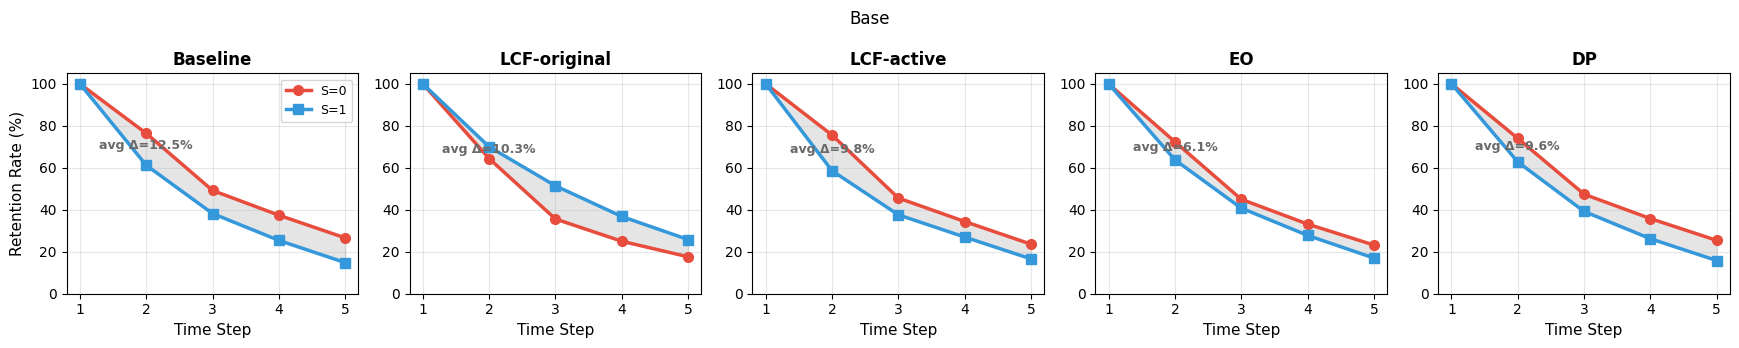

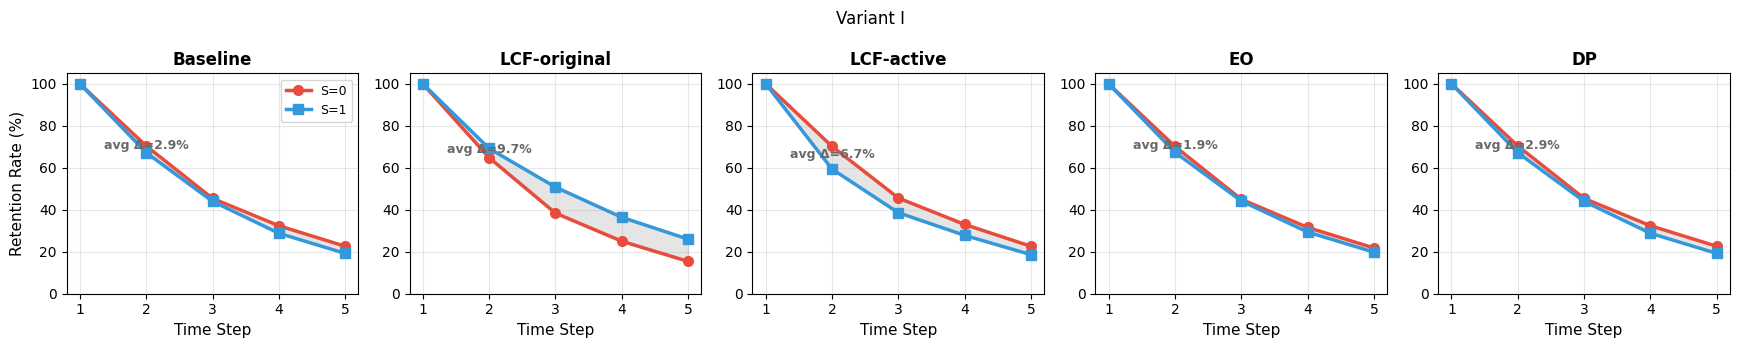

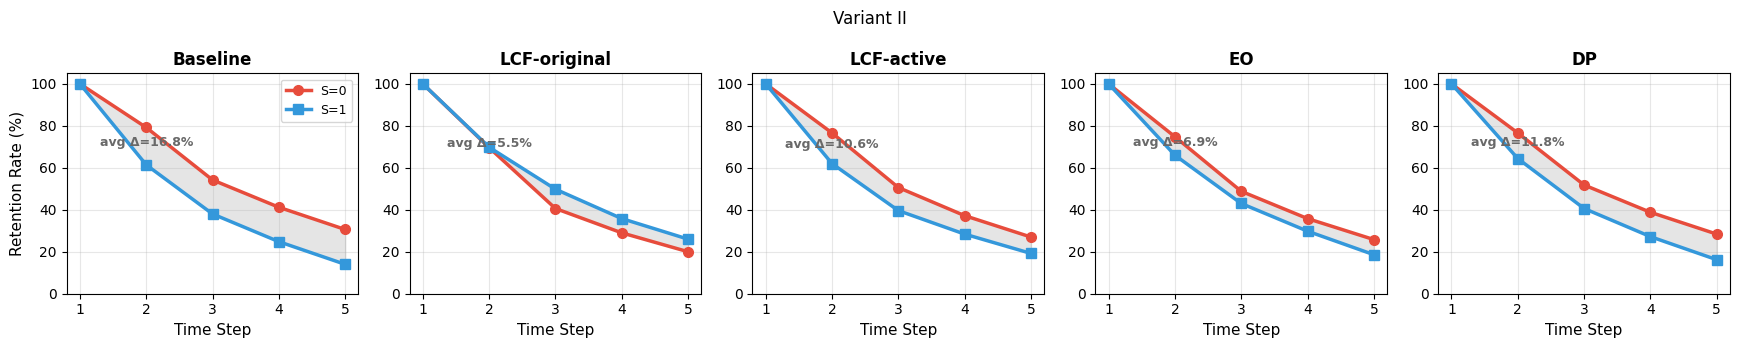

In [27]:
def plot_group_retention(dataset_name, experiment):
    results = experiment['metrics']
    results_no_dynamic = experiment['metrics_no_opt_out']
    all_metrics = experiment.get('detailed_metrics', {})
    steps = list(range(1, len(results['Baseline']['S=0']) + 1))
    methods = list(results)
    method_colors = {'Baseline': '#E74C3C', 'LCF-original': '#3498DB', 'LCF-active': '#F39C12', 'EO': '#27AE60', 'DP': '#9B59B6'}
    dataset_slug = {'Base': 'base', 'Variant I': 'variant1', 'Variant II': 'variant2'}[dataset_name]
    #Figure 1 Retention rates by group (one panel per model)
    fig, axes = plt.subplots(1, len(methods), figsize=(3.5 * len(methods), 3.5))
    colors = {'S=0': '#E74C3C', 'S=1': '#3498DB'}

    methods = list(results.keys())
    for idx, method in enumerate(methods):
        ax = axes[idx]
        ax.plot(steps, results[method]['S=0'], 'o-', color=colors['S=0'], label='S=0', linewidth=2.5, markersize=7)
        ax.plot(steps, results[method]['S=1'], 's-', color=colors['S=1'], label='S=1', linewidth=2.5, markersize=7)
        ax.fill_between(steps, results[method]['S=0'], results[method]['S=1'], alpha=0.2, color='gray')

        #disparity_t2 = results[method]['disparity'][1]
        avg_disparity = np.mean(results[method]['disparity'][1:])   # skip step 1 which is always 0, average for t 2-5
        mid_y = (results[method]['S=0'][1] + results[method]['S=1'][1]) / 2
        ax.annotate(f'avg Δ={avg_disparity:.1f}%', xy=(2, mid_y), fontsize=9, ha='center', color='dimgray', fontweight='bold')

        ax.set_title(method, fontsize=12, fontweight='bold')
        ax.set_ylim(0, 105)
        ax.set_xticks(steps)
        ax.set_xlabel('Time Step', fontsize=11)
        ax.grid(True, alpha=0.3)
        if idx == 0:
            ax.set_ylabel('Retention Rate (%)', fontsize=11)
            ax.legend(loc='upper right', fontsize=9)

    fig.suptitle(dataset_name)
    plt.tight_layout()
    run_results.save_figure(fig, dataset_name, 'group_retention')
    plt.show()

for dataset_name, experiment in experiments.items():
    plot_group_retention(dataset_name, experiment)


## Plot retention and relative retention

Overlay the `S=0/S=1` retention ratio on the group retention plots to show the direction as well as the size of participation differences.

Repeat the plot for all three datasets, label each figure, and prefix any saved filenames with the dataset name.


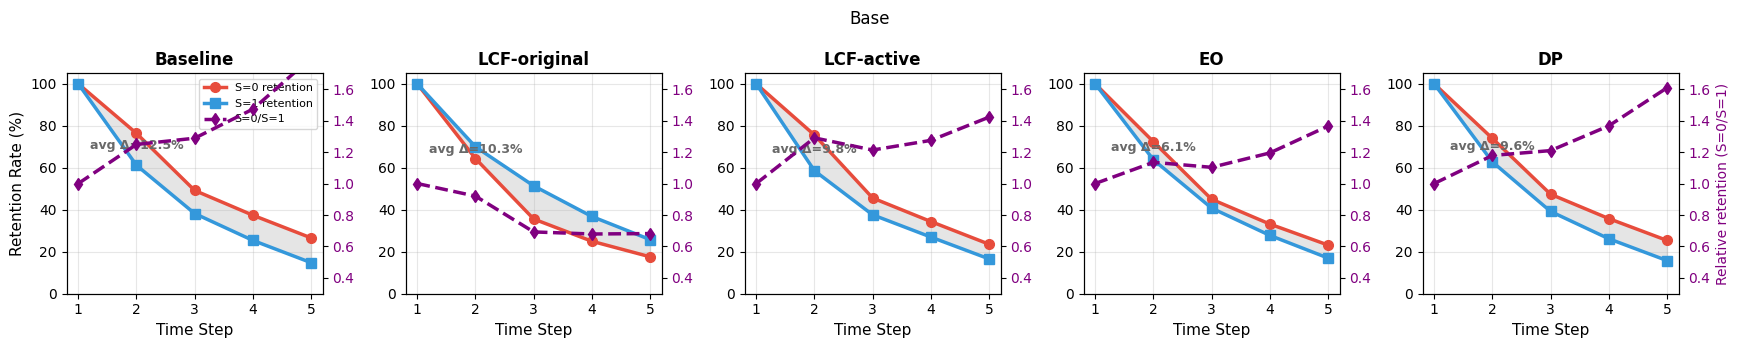

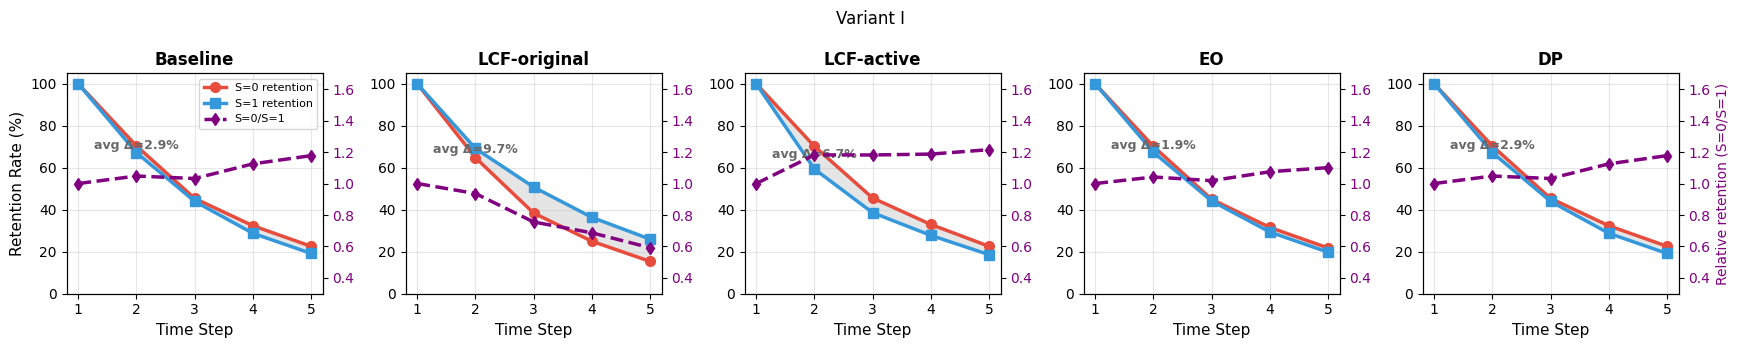

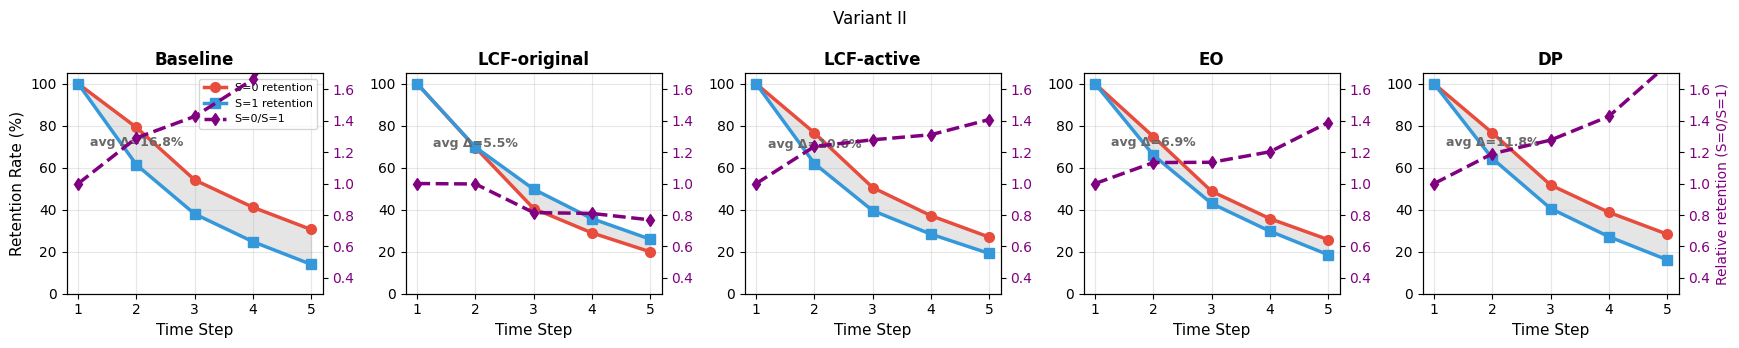

In [28]:
def plot_relative_retention(dataset_name, experiment):
    results = experiment['metrics']
    results_no_dynamic = experiment['metrics_no_opt_out']
    all_metrics = experiment.get('detailed_metrics', {})
    steps = list(range(1, len(results['Baseline']['S=0']) + 1))
    methods = list(results)
    method_colors = {'Baseline': '#E74C3C', 'LCF-original': '#3498DB', 'LCF-active': '#F39C12', 'EO': '#27AE60', 'DP': '#9B59B6'}
    dataset_slug = {'Base': 'base', 'Variant I': 'variant1', 'Variant II': 'variant2'}[dataset_name]
    # Figure 2 Retention by group + relative retention ratio (twin axis, one panel per model)
    fig, axes = plt.subplots(1, len(methods), figsize=(3.5 * len(methods), 3.5))
    left_colors = {'S=0': '#E74C3C', 'S=1': '#3498DB'}
    ratio_color = 'purple'

    for idx, method in enumerate(methods):
        ax = axes[idx]
        ax2 = ax.twinx()

        s0 = np.array(results[method]['S=0'], dtype=float)
        s1 = np.array(results[method]['S=1'], dtype=float)
        ratio = np.divide(s0, s1, out=np.full_like(s0, np.nan), where=(s1 != 0))

        l1, = ax.plot(steps, s0, 'o-', color=left_colors['S=0'], label='S=0 retention', linewidth=2.5, markersize=7)
        l2, = ax.plot(steps, s1, 's-', color=left_colors['S=1'], label='S=1 retention', linewidth=2.5, markersize=7)
        ax.fill_between(steps, s0, s1, alpha=0.2, color='gray')
        l3, = ax2.plot(steps, ratio, 'd--', color=ratio_color, label='S=0/S=1', linewidth=2.5, markersize=6)

        #disparity_t2 = results[method]['disparity'][1]
        avg_disparity = np.mean(results[method]['disparity'][1:])   # skip step 1 which is always 0, average for t 2-5
        mid_y = (s0[1] + s1[1]) / 2
        ax.annotate(f'avg Δ={avg_disparity:.1f}%', xy=(2, mid_y), fontsize=9, ha='center', color='dimgray', fontweight='bold')

        ax.set_title(method, fontsize=12, fontweight='bold')
        ax.set_ylim(0, 105)
        ax.set_xticks(steps)
        ax.set_xlabel('Time Step', fontsize=11)
        ax.grid(True, alpha=0.3)

        if idx == len(methods) - 1:
            ax2.set_ylabel('Relative retention (S=0/S=1)', fontsize=10, color=ratio_color)
        ax2.tick_params(axis='y', labelcolor=ratio_color)
        ax2.set_ylim(0.3, 1.7)

        if idx == 0:
            ax.set_ylabel('Retention Rate (%)', fontsize=11)
            ax.legend(handles=[l1, l2, l3], loc='upper right', fontsize=8)

    fig.suptitle(dataset_name)
    plt.tight_layout()
    run_results.save_figure(fig, dataset_name, 'group_retention_and_ratio')
    plt.show()

for dataset_name, experiment in experiments.items():
    plot_relative_retention(dataset_name, experiment)


## Plot long-term unfairness across models

Compare absolute long-term unfairness trajectories in one figure and save PNG and PDF copies.

Repeat the plot for all three datasets, label each figure, and prefix any saved filenames with the dataset name.


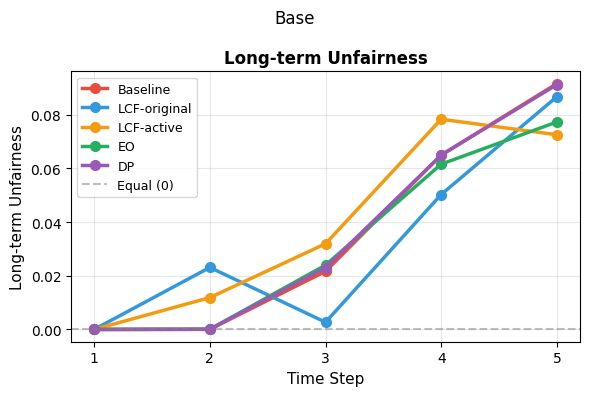

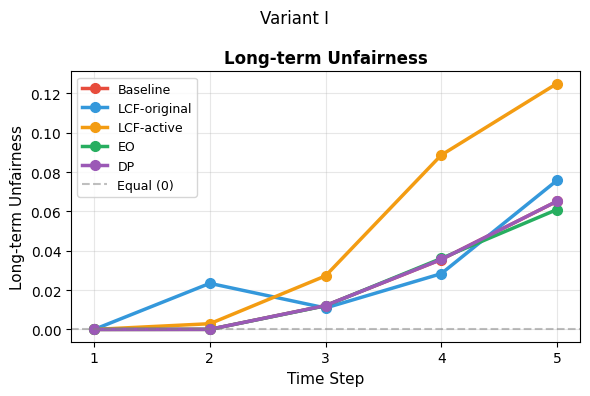

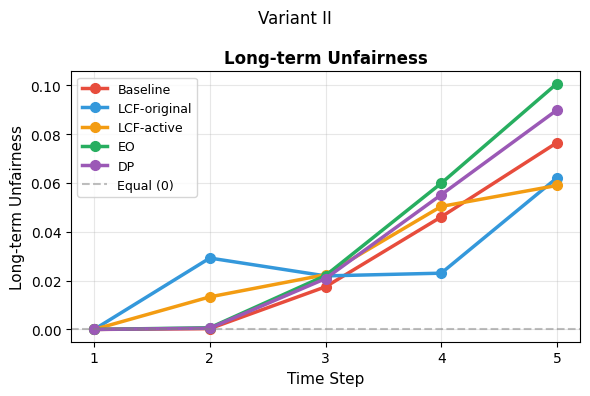

In [29]:
def plot_long_term_unfairness(dataset_name, experiment):
    results = experiment['metrics']
    results_no_dynamic = experiment['metrics_no_opt_out']
    all_metrics = experiment.get('detailed_metrics', {})
    steps = list(range(1, len(results['Baseline']['S=0']) + 1))
    methods = list(results)
    method_colors = {'Baseline': '#E74C3C', 'LCF-original': '#3498DB', 'LCF-active': '#F39C12', 'EO': '#27AE60', 'DP': '#9B59B6'}
    dataset_slug = {'Base': 'base', 'Variant I': 'variant1', 'Variant II': 'variant2'}[dataset_name]
    # Figure 3 Merged long-term unfairness (single plot)
    method_colors = {'Baseline': '#E74C3C', 'LCF-original': '#3498DB', 'LCF-active': '#F39C12', 'EO': '#27AE60', 'DP': '#9B59B6', 'PE': '#F39C12' }

    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    for method in methods:
        ax.plot(steps, results[method]['unfairness'], 'o-', color=method_colors[method], label=method, linewidth=2.5, markersize=7)

    ax.axhline(y=0.0, color='gray', linestyle='--', alpha=0.5, label='Equal (0)')
    ax.set_xlabel('Time Step', fontsize=11)
    ax.set_ylabel('Long-term Unfairness', fontsize=11)
    ax.set_title('Long-term Unfairness', fontsize=12, fontweight='bold')
    ax.set_xticks(steps)
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)
    fig.suptitle(dataset_name)
    plt.tight_layout()
    run_results.save_figure(fig, dataset_name, 'long_term_unfairness_merged')
    plt.show()


for dataset_name, experiment in experiments.items():
    plot_long_term_unfairness(dataset_name, experiment)


## Compare unfairness with and without opt-out

Plot both participation settings, comparing both LCF optimizers on a separate axis so its scale does not obscure the other models.

Repeat the plot for all three datasets, label each figure, and prefix any saved filenames with the dataset name.


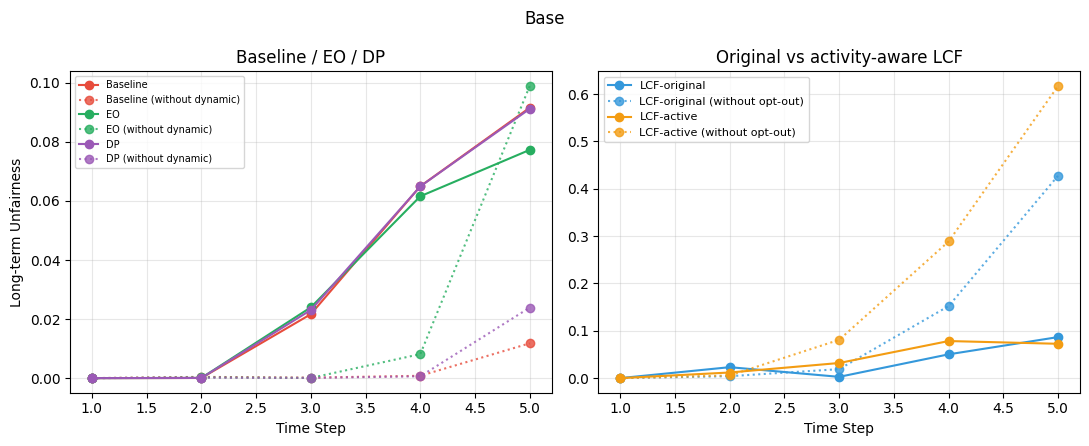

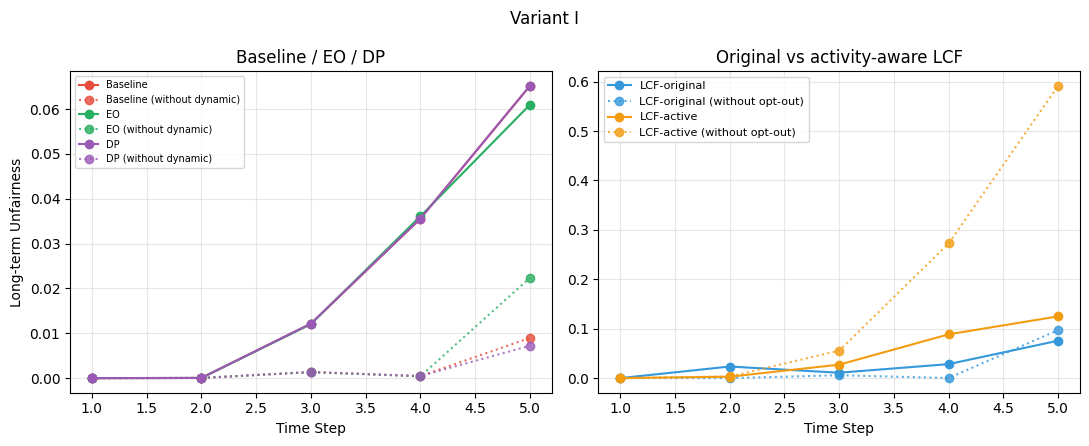

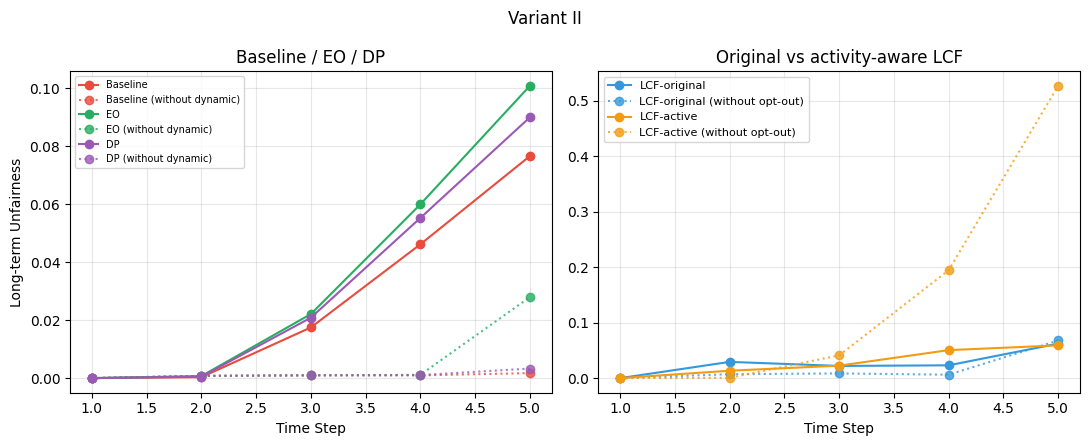

In [30]:
def plot_opt_out_comparison(dataset_name, experiment):
    results = experiment['metrics']
    results_no_dynamic = experiment['metrics_no_opt_out']
    all_metrics = experiment.get('detailed_metrics', {})
    steps = list(range(1, len(results['Baseline']['S=0']) + 1))
    methods = list(results)
    method_colors = {'Baseline': '#E74C3C', 'LCF-original': '#3498DB', 'LCF-active': '#F39C12', 'EO': '#27AE60', 'DP': '#9B59B6'}
    dataset_slug = {'Base': 'base', 'Variant I': 'variant1', 'Variant II': 'variant2'}[dataset_name]
    # fig separating LCF from others to avoid stretching y-axis.
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    # Left: everything except LCF
    for method in ['Baseline', 'EO', 'DP']:
        axes[0].plot(steps, results[method]['unfairness'], 'o-', color=method_colors[method], label=method)
        axes[0].plot(steps, results_no_dynamic[method]['unfairness'], 'o:', color=method_colors[method],
                     label=f'{method} (without dynamic)', alpha=0.8)
    axes[0].set_title('Baseline / EO / DP'); axes[0].set_xlabel('Time Step'); axes[0].set_ylabel('Long-term Unfairness')
    axes[0].legend(fontsize=7); axes[0].grid(alpha=0.3)

    # Compare both LCF optimizers with the same reported fairness metric.
    for method in ['LCF-original', 'LCF-active']:
        axes[1].plot(steps, results[method]['unfairness'], 'o-', color=method_colors[method], label=method)
        axes[1].plot(steps, results_no_dynamic[method]['unfairness'], 'o:', color=method_colors[method],
                     label=f'{method} (without opt-out)', alpha=0.8)
    axes[1].set_title('Original vs activity-aware LCF')
    axes[1].set_xlabel('Time Step'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

    fig.suptitle(dataset_name)
    plt.tight_layout()
    run_results.save_figure(fig, dataset_name, 'opt_out_comparison')
    plt.show()

for dataset_name, experiment in experiments.items():
    plot_opt_out_comparison(dataset_name, experiment)


## Tabulate participation and approval metrics

Reuse stored trajectories to report active group counts, retention ratios, stepwise retention, and signed approval-rate differences among active applicants.


In [31]:
# Detailed metrics table reuses results_lr/lcf/eo/dp directly,
# NO second run_simulation() call needed (the original notebook's run_and_store() duplicated work that results_lr/lcf/eo/dp already contain).
def compute_detailed_metrics(s, As, Ds, Ys):
    s = np.array(s)
    n_s0_total = np.sum(s == 0)
    n_s1_total = np.sum(s == 1)

    print("Step | N(S=0) | N(S=1) | S=0 Share | Rep. Ratio | H(S=0) | H(S=1) | H.Ratio | Signed Δ(Approval)")
    print("-" * 120)

    metrics = {'s0_share': [], 'rep_ratio': [], 'signed_delta': [], 'retention_s0': [], 'retention_s1': [],
               'disparity': [], 'h_s0': [], 'h_s1': [], 'h_ratio': []}

    prev_active_s0 = prev_active_s1 = None

    for t in range(len(As)):
        A_t = np.array(As[t])
        D_t = np.array(Ds[t])

        active_s0 = np.sum((s == 0) & (A_t == 1))
        active_s1 = np.sum((s == 1) & (A_t == 1))
        total_active = active_s0 + active_s1
        s0_share = active_s0 / total_active if total_active > 0 else 0

        retention_s0 = (active_s0 / n_s0_total) * 100 if n_s0_total > 0 else np.nan
        retention_s1 = (active_s1 / n_s1_total) * 100 if n_s1_total > 0 else np.nan
        disparity = abs(retention_s0 - retention_s1)
        rep_ratio = retention_s0 / retention_s1 if retention_s1 and retention_s1 > 0 else np.nan

        if t == 0:
            h_s0 = h_s1 = 1.0
        else:
            h_s0 = (active_s0 / prev_active_s0) if (prev_active_s0 is not None and prev_active_s0 > 0) else np.nan
            h_s1 = (active_s1 / prev_active_s1) if (prev_active_s1 is not None and prev_active_s1 > 0) else np.nan
        h_ratio = (h_s0 / h_s1) if (h_s1 is not None and not np.isnan(h_s1) and h_s1 != 0) else np.nan

        prev_active_s0, prev_active_s1 = active_s0, active_s1

        active_mask = A_t == 1
        if active_s0 > 0 and active_s1 > 0:
            approval_s0 = np.mean(D_t[(s == 0) & active_mask])
            approval_s1 = np.mean(D_t[(s == 1) & active_mask])
            signed_delta = approval_s0 - approval_s1
        else:
            signed_delta = np.nan

        for k, v in zip(['s0_share','rep_ratio','signed_delta','retention_s0','retention_s1','disparity','h_s0','h_s1','h_ratio'],
                         [s0_share, rep_ratio, signed_delta, retention_s0, retention_s1, disparity, h_s0, h_s1, h_ratio]):
            metrics[k].append(v)

        print(f"  {t+1}  |  {active_s0:4d}  |  {active_s1:4d}  |   {s0_share:.2f}    |    {rep_ratio:6.2f}  |"
              f"  {h_s0:5.2f}  |  {h_s1:5.2f}  |  {h_ratio:6.2f}  |      {signed_delta:+.3f}")

    return metrics


def collect_detailed_metrics(trajectories):
    metrics = {}
    for model_name, (s, Xs, Ys, Ds, As) in trajectories.items():
        print(f'\n=== {model_name} ===')
        metrics[model_name] = compute_detailed_metrics(s, As, Ds, Ys)
    return metrics


detailed_metrics_base = collect_detailed_metrics(trajectories_base)
detailed_metrics_variant1 = collect_detailed_metrics(trajectories_variant1)
detailed_metrics_variant2 = collect_detailed_metrics(trajectories_variant2)

experiments['Base']['detailed_metrics'] = detailed_metrics_base
experiments['Variant I']['detailed_metrics'] = detailed_metrics_variant1
experiments['Variant II']['detailed_metrics'] = detailed_metrics_variant2



=== Baseline ===
Step | N(S=0) | N(S=1) | S=0 Share | Rep. Ratio | H(S=0) | H(S=1) | H.Ratio | Signed Δ(Approval)
------------------------------------------------------------------------------------------------------------------------
  1  |   500  |   500  |   0.50    |      1.00  |   1.00  |   1.00  |    1.00  |      +0.082
  2  |   382  |   306  |   0.56    |      1.25  |   0.76  |   0.61  |    1.25  |      +0.037
  3  |   246  |   191  |   0.56    |      1.29  |   0.64  |   0.62  |    1.03  |      +0.078
  4  |   187  |   127  |   0.60    |      1.47  |   0.76  |   0.66  |    1.14  |      +0.037
  5  |   133  |    74  |   0.64    |      1.80  |   0.71  |   0.58  |    1.22  |      +0.068

=== LCF-original ===
Step | N(S=0) | N(S=1) | S=0 Share | Rep. Ratio | H(S=0) | H(S=1) | H.Ratio | Signed Δ(Approval)
------------------------------------------------------------------------------------------------------------------------
  1  |   500  |   500  |   0.50    |      1.00  |   1.00  |

## Plot participation ratios and approval differences

Plot and save relative retention, signed approval-rate differences, and stepwise retention ratios for each model.

Repeat the plot for all three datasets, label each figure, and prefix any saved filenames with the dataset name.


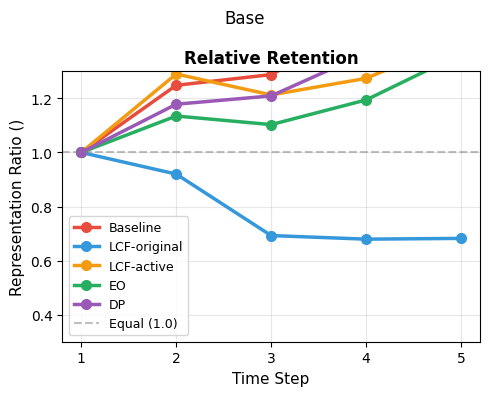

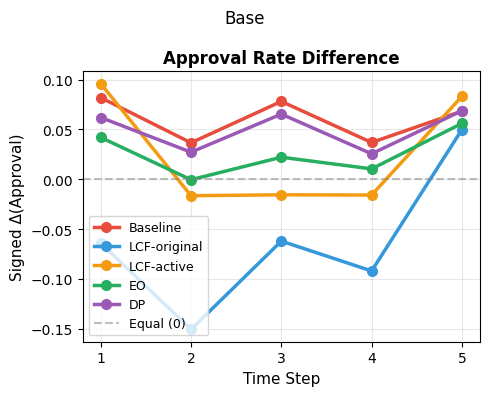

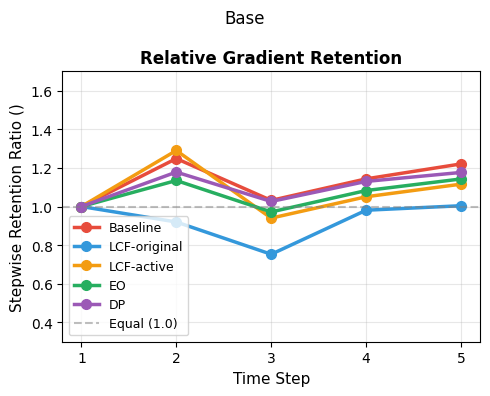

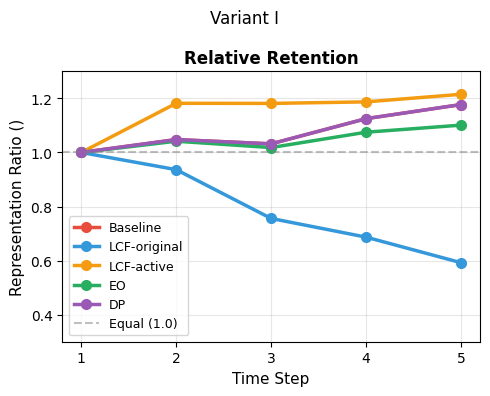

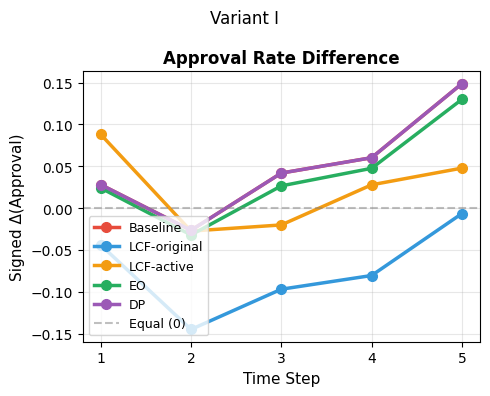

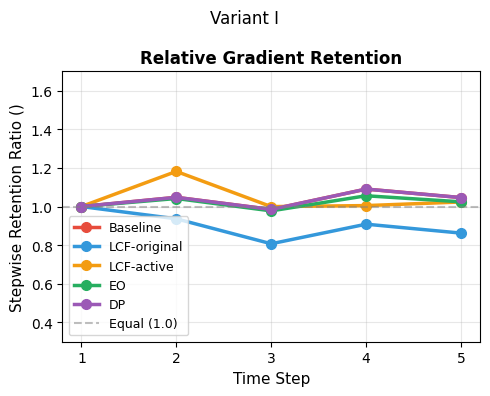

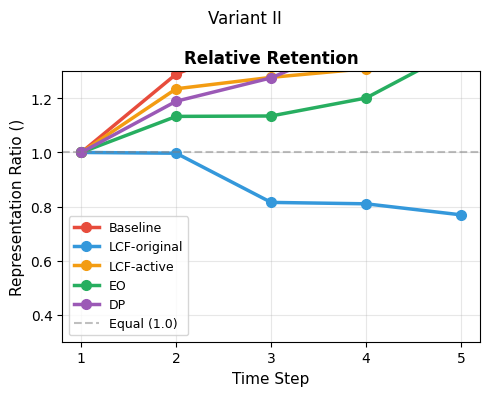

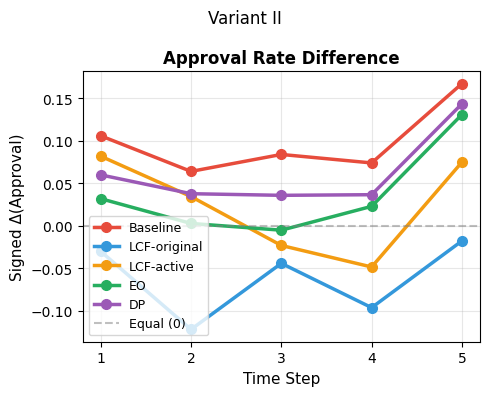

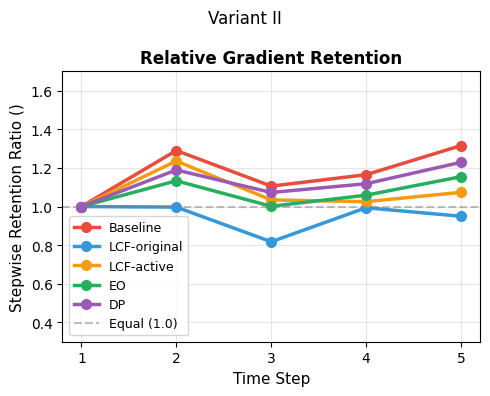

In [32]:
def plot_detailed_metrics(dataset_name, experiment):
    results = experiment['metrics']
    results_no_dynamic = experiment['metrics_no_opt_out']
    all_metrics = experiment.get('detailed_metrics', {})
    steps = list(range(1, len(results['Baseline']['S=0']) + 1))
    methods = list(results)
    method_colors = {'Baseline': '#E74C3C', 'LCF-original': '#3498DB', 'LCF-active': '#F39C12', 'EO': '#27AE60', 'DP': '#9B59B6'}
    dataset_slug = {'Base': 'base', 'Variant I': 'variant1', 'Variant II': 'variant2'}[dataset_name]
    # Figures 4-6 -- H-linecharts (rep_ratio, signed_delta, h_ratio)
    single_figsize = (5, 4)

    fig, ax = plt.subplots(1, 1, figsize=single_figsize)
    for method in methods:
        ax.plot(steps, all_metrics[method]['rep_ratio'], 'o-', color=method_colors[method], label=method, linewidth=2.5, markersize=7)
    ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Equal (1.0)')
    ax.set_xlabel('Time Step', fontsize=11); ax.set_ylabel('Representation Ratio ()', fontsize=11)
    ax.set_title('Relative Retention', fontsize=12, fontweight='bold')
    ax.set_ylim(0.3, 1.3); ax.set_xticks(steps); ax.legend(loc='lower left', fontsize=9); ax.grid(True, alpha=0.3)
    fig.suptitle(dataset_name)
    plt.tight_layout(); run_results.save_figure(fig, dataset_name, 'relative_retention'); plt.show()

    fig, ax = plt.subplots(1, 1, figsize=single_figsize)
    for method in methods:
        ax.plot(steps, all_metrics[method]['signed_delta'], 'o-', color=method_colors[method], label=method, linewidth=2.5, markersize=7)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5, label='Equal (0)')
    ax.set_xlabel('Time Step', fontsize=11); ax.set_ylabel('Signed Δ(Approval)', fontsize=11)
    ax.set_title('Approval Rate Difference', fontsize=12, fontweight='bold')
    ax.set_xticks(steps); ax.legend(loc='lower left', fontsize=9); ax.grid(True, alpha=0.3)
    fig.suptitle(dataset_name)
    plt.tight_layout(); run_results.save_figure(fig, dataset_name, 'approval_rate_difference'); plt.show()

    fig, ax = plt.subplots(1, 1, figsize=single_figsize)
    for method in methods:
        ax.plot(steps, all_metrics[method]['h_ratio'], 'o-', color=method_colors[method], label=method, linewidth=2.5, markersize=7)
    ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Equal (1.0)')
    ax.set_xlabel('Time Step', fontsize=11); ax.set_ylabel('Stepwise Retention Ratio ()', fontsize=11)
    ax.set_title('Relative Gradient Retention', fontsize=12, fontweight='bold')
    ax.set_xticks(steps); ax.set_ylim(0.3, 1.7); ax.legend(loc='lower left', fontsize=9); ax.grid(True, alpha=0.3)
    fig.suptitle(dataset_name)
    plt.tight_layout(); run_results.save_figure(fig, dataset_name, 'relative_gradient_retention'); plt.show()

for dataset_name, experiment in experiments.items():
    plot_detailed_metrics(dataset_name, experiment)


## Define seeded evaluation without opt-out

Define helpers that repeat simulations without population exit and summarize final approval-rate disparity across seeds. This differs from the retention-disparity summary used with opt-out.


In [33]:
def run_no_dynamic_seeded(model, model_name, bank, agent, steps=5, run_seed=2026):
    np.random.seed(run_seed)
    s, adj, edges, Xs, Ys, Ds, Ps, Os, Us, As = run_simulation_no_dynamic(
        decision_model=model,
        repayment_model=bank,
        agent=agent,
        steps=steps,
        enforce_demographic_mixing=True,
        k_same=8,
        k_other=2,
        directed=False,
        graph_seed=run_seed,
        seed=run_seed,
        decision_coef=0.8,
        repayment_coef=0.8,
    )
    return s, Xs, Ys, Ds, As


def run_multiseed_no_dynamic(model, model_name, bank, agent, steps=5, seeds=(2026, 7, 13, 42, 99)):
    disparities = []
    for sd in seeds:
        s, Xs, Ys, Ds, As = run_no_dynamic_seeded(model, model_name, bank, agent, steps, sd)
        s_arr = np.array(s)
        D_final = np.array(Ds[-1])
        approval_s0 = D_final[s_arr == 0].mean() * 100
        approval_s1 = D_final[s_arr == 1].mean() * 100
        disparities.append(abs(approval_s0 - approval_s1))
    run_results.summary('final_approval_disparity_no_opt_out', disparities, seeds, 'approval_disparity', 'percentage_points')
    return np.mean(disparities), np.std(disparities), disparities

## Compare approval disparity without opt-out

Print the mean, standard deviation, and individual final approval-rate disparities for each model across five seeds.


In [34]:
for dataset_name, experiment in experiments.items():
    print(f'\n=== {dataset_name}: approval disparity without opt-out ===')
    experiment['approval_disparity_no_opt_out'] = {}
    for model_name, model in experiment['models'].items():
        summary = run_multiseed_no_dynamic(model, model_name, experiment['bank'], experiment['test_agent'])
        experiment['approval_disparity_no_opt_out'][model_name] = summary
        mean_d, std_d, all_d = summary
        print(f"{model_name}: {mean_d:.1f}% ± {std_d:.1f}% (runs: {[round(x, 1) for x in all_d]})")



=== Base: approval disparity without opt-out ===
Baseline: 8.5% ± 4.3% (runs: [np.float64(6.2), np.float64(9.2), np.float64(16.6), np.float64(5.8), np.float64(4.8)])
LCF-original: 4.0% ± 1.4% (runs: [np.float64(3.2), np.float64(3.0), np.float64(3.4), np.float64(3.8), np.float64(6.8)])
LCF-active: 4.9% ± 3.7% (runs: [np.float64(3.0), np.float64(8.0), np.float64(10.4), np.float64(2.6), np.float64(0.4)])
EO: 7.7% ± 5.1% (runs: [np.float64(5.0), np.float64(11.0), np.float64(16.0), np.float64(3.2), np.float64(3.2)])
DP: 8.0% ± 4.7% (runs: [np.float64(5.2), np.float64(9.6), np.float64(16.4), np.float64(4.0), np.float64(4.6)])

=== Variant I: approval disparity without opt-out ===
Baseline: 7.9% ± 0.8% (runs: [np.float64(8.4), np.float64(7.6), np.float64(9.0), np.float64(7.6), np.float64(6.8)])
LCF-original: 6.8% ± 1.0% (runs: [np.float64(5.4), np.float64(6.4), np.float64(6.8), np.float64(6.8), np.float64(8.4)])
LCF-active: 1.4% ± 1.3% (runs: [np.float64(0.2), np.float64(1.0), np.float64(0.0

## Compare final unfairness across seeds

Summarize final long-term unfairness with and without opt-out. These calls use the shared loop’s default mixing of eight same-group and two other-group neighbors.


In [35]:
def unfairness_multiseed(model, bank, agent, dynamic=True, seeds=(2026, 7, 13, 42, 99)):
    finals = []
    for sd in seeds:
        np.random.seed(sd)
        if dynamic:
            s, adj, edges, Xs, Ys, Ds, Ps, Os, Us, As = run_simulation_resynced(
                model, agent, 5, repayment_model=bank, graph_seed=sd, seed=sd)
        else:
            s, adj, edges, Xs, Ys, Ds, Ps, Os, Us, As = run_simulation_no_dynamic(
                model, agent, 5, repayment_model=bank, graph_seed=sd, seed=sd)
        m = extract_metrics((s, Xs, Ys, Ds, As), model)
        finals.append(m['unfairness'][-1])
    run_results.summary('final_unfairness', finals, seeds, 'unfairness', 'fraction')
    return np.mean(finals), np.std(finals), finals


for dataset_name, experiment in experiments.items():
    print(f'\n=== {dataset_name}: final long-term unfairness ===')
    experiment['unfairness_summary'] = {}
    for model_name, model in experiment['models'].items():
        with_opt_out = unfairness_multiseed(model, experiment['bank'], experiment['test_agent'], dynamic=True)
        without_opt_out = unfairness_multiseed(model, experiment['bank'], experiment['test_agent'], dynamic=False)
        experiment['unfairness_summary'][model_name] = {'with_opt_out': with_opt_out, 'without_opt_out': without_opt_out}
        m_with, s_with, _ = with_opt_out
        m_without, s_without, _ = without_opt_out
        print(f"{model_name}: with={m_with:.3f}±{s_with:.3f} without={m_without:.3f}±{s_without:.3f} ratio={m_without/m_with:.1f}x")



=== Base: final long-term unfairness ===
Baseline: with=0.087±0.014 without=0.010±0.001 ratio=0.1x
LCF-original: with=0.054±0.029 without=0.417±0.006 ratio=7.8x
LCF-active: with=0.107±0.030 without=0.617±0.008 ratio=5.8x
EO: with=0.085±0.021 without=0.092±0.006 ratio=1.1x
DP: with=0.099±0.019 without=0.023±0.002 ratio=0.2x

=== Variant I: final long-term unfairness ===
Baseline: with=0.069±0.020 without=0.010±0.001 ratio=0.1x
LCF-original: with=0.070±0.014 without=0.094±0.004 ratio=1.3x
LCF-active: with=0.134±0.030 without=0.581±0.007 ratio=4.3x
EO: with=0.069±0.022 without=0.023±0.001 ratio=0.3x
DP: with=0.069±0.020 without=0.010±0.001 ratio=0.1x

=== Variant II: final long-term unfairness ===
Baseline: with=0.074±0.009 without=0.001±0.001 ratio=0.0x
LCF-original: with=0.067±0.007 without=0.074±0.004 ratio=1.1x
LCF-active: with=0.078±0.024 without=0.536±0.012 ratio=6.8x
EO: with=0.096±0.011 without=0.022±0.005 ratio=0.2x
DP: with=0.097±0.014 without=0.003±0.001 ratio=0.0x


## Summarize average retention disparity across seeds

Average each run’s retention disparities after the initial step, then report the mean and standard deviation across seeds. These calls also use the default eight/two neighborhood mixing.


In [36]:
def avg_disparity_seeded(model, bank, agent, seeds=(2026, 7, 13, 42, 99)):
    avg_disparities = []
    for sd in seeds:
        np.random.seed(sd)
        s, adj, edges, Xs, Ys, Ds, Ps, Os, Us, As = run_simulation_resynced(
            model, agent, 5, repayment_model=bank, graph_seed=sd, seed=sd)
        s_arr = np.array(s)
        step_disparities = []
        for A_t in As:
            A_t = np.array(A_t)
            r0 = A_t[s_arr == 0].mean() * 100
            r1 = A_t[s_arr == 1].mean() * 100
            step_disparities.append(abs(r0 - r1))
        avg_disparities.append(np.mean(step_disparities[1:]))  # skip step 1, always 0
    run_results.summary('average_retention_disparity_steps_2_to_T', avg_disparities, seeds, 'disparity', 'percentage_points')
    return np.mean(avg_disparities), np.std(avg_disparities), avg_disparities


for dataset_name, experiment in experiments.items():
    print(f'\n=== {dataset_name}: average retention disparity ===')
    experiment['average_retention_disparity'] = {}
    for model_name, model in experiment['models'].items():
        summary = avg_disparity_seeded(model, experiment['bank'], experiment['test_agent'])
        experiment['average_retention_disparity'][model_name] = summary
        mean_d, std_d, all_d = summary
        print(f"{model_name}: avg_disparity={mean_d:.1f}±{std_d:.1f} (runs: {[round(x, 1) for x in all_d]})")



=== Base: average retention disparity ===
Baseline: avg_disparity=10.3±1.2 (runs: [np.float64(12.5), np.float64(9.1), np.float64(10.1), np.float64(9.5), np.float64(10.1)])
LCF-original: avg_disparity=10.3±2.1 (runs: [np.float64(10.3), np.float64(12.2), np.float64(6.6), np.float64(10.0), np.float64(12.3)])
LCF-active: avg_disparity=6.8±2.9 (runs: [np.float64(9.8), np.float64(1.4), np.float64(7.8), np.float64(6.6), np.float64(8.3)])
EO: avg_disparity=4.8±0.7 (runs: [np.float64(6.1), np.float64(4.5), np.float64(5.1), np.float64(4.3), np.float64(4.2)])
DP: avg_disparity=7.5±1.1 (runs: [np.float64(9.6), np.float64(6.6), np.float64(7.5), np.float64(6.8), np.float64(6.7)])

=== Variant I: average retention disparity ===
Baseline: avg_disparity=3.0±0.6 (runs: [np.float64(2.9), np.float64(1.9), np.float64(3.7), np.float64(3.1), np.float64(3.3)])
LCF-original: avg_disparity=11.1±1.9 (runs: [np.float64(9.7), np.float64(11.5), np.float64(11.1), np.float64(14.4), np.float64(8.7)])
LCF-active: avg_

## Save the complete run: figures, numerical results, and settings
The CSV contains one value per row with dataset, model, opt-out flag, seed, time step, metric, statistic, and unit. `figure_*` rows match the plots; evaluation rows contain all captured seeds. Summary rows retain each seed value plus the mean and standard deviation. Settings and fitted parameters are recorded in `run_metadata.json`. Export reuses the simulated trajectories and does not retrain models.


In [37]:
# Metadata uses the actual fitted objects and training arguments from this run.
def describe_object(obj, names):
    return {name: getattr(obj, name) for name in names if hasattr(obj, name)}

import inspect
import hashlib
source_split_defaults = {key: value.default for key, value in
    inspect.signature(split_feature_pools).parameters.items()
    if value.default is not inspect.Parameter.empty}
code_files = [src_path.parents[1] / "local" / "BAF_refactor.ipynb", *sorted(src_path.glob("*.py"))]
run_metadata = dict(
    source_split_defaults=source_split_defaults,
    code_sha256={str(path.relative_to(src_path.parents[1])):
                 hashlib.sha256(path.read_bytes()).hexdigest() for path in code_files},
    notebook="local/BAF_refactor.ipynb", random_seed=RANDOM_SEED,
    simulation_defaults=SIMULATION_SETTINGS,
    fairness_denominator_clip=inspect.signature(safe_compute_post_long_cond_probs).parameters["clip"].default,
    groups={"S=0": "customer_age < 50", "S=1": "customer_age >= 50"},
    feature_order=["credit_risk_score", "proposed_credit_limit"],
    credit_limit_coupling=dict(
        coefficients=credit_limit_coupling.model.coef_,
        intercept=credit_limit_coupling.model.intercept_,
        residual_std=credit_limit_coupling.residual_std,
        fitted_on="Base training partition"),
    datasets={},
)
for dataset_name, experiment in experiments.items():
    train_agent, test_agent = experiment['train_agent'], experiment['test_agent']
    run_metadata['datasets'][dataset_name] = dict(
        input_file=str(datasets_paths[dataset_name]),
        input_size_bytes=datasets_paths[dataset_name].stat().st_size,
        input_modified_ns=datasets_paths[dataset_name].stat().st_mtime_ns,
        train_agent=describe_object(train_agent, ['n_samples', 'seed', 'eps', 'base', 'protect_ratio']),
        test_agent=describe_object(test_agent, ['n_samples', 'seed', 'eps', 'base', 'protect_ratio']),
        training=train_agent.training_settings,
        scaler=describe_object(train_agent.scaler, ['mean_', 'scale_']),
        bank_parameters=experiment['bank'].params,
        models={name: dict(class_name=type(model).__name__,
            **describe_object(model, ['params', 'lr', 'l2_reg', 'sf_reg', 'lf_reg', 'tao']),
            sklearn_parameters=(model.model.get_params() if hasattr(model, 'model')
                                and hasattr(model.model, 'get_params') else None))
            for name, model in experiment['models'].items()},
    )

all_results_table = run_results.export(
    experiments, extract_metrics, compute_detailed_metrics, run_metadata)
print(f"Saved {len(all_results_table):,} numerical results to {run_results.folder / 'all_results.csv'}")
print(f"Saved {len(run_results.figures)} figures in PNG and PDF, plus run_metadata.json, in the same folder.")


Saved 24,075 numerical results to /Users/jh22215/Documents/GitHub/Delayed-Fairness-Project/local/results/20260917T135330_829319Z_7e8875/all_results.csv
Saved 21 figures in PNG and PDF, plus run_metadata.json, in the same folder.
